# CAB420, Transformers, Additional Example 1: Masked Auto-Encoders
Dr Simon Denman (s.denman@qut.edu.au)

## Overview

Transformers take a lot of data to train. This is particularly true for the sort of transformer models that we see out in the wild from the likes of OpenAI, Google, and Facebook. These models are so demanding to train that it's become very common to use self-supervised training methods to help pre-train networks. 

This trend was first started for natural language processing (where transformers originated), where "Masked Language Modelling" was proposed. Essentially, the model was fed a piece of text with a bunch of words masked out and replaced with a blank token (a mask token). The network then had to predict what words should be there. Using this approach, any old lump of text can be used to help train the network (if you were wondering how Chat-GPT is trained on anything and everything this is how, all that data has not actually been labelled), and over time the network can start to learn patterns and relationships between words. While the resulting pre-trained model is not necessarily useful for anything directly on it's own, if trained for a sufficiently long period of time it should have learnt a pretty good representation which can be easily adapted to other tasks via fine-tuning (in some instances too, the self-supervised objective will be learned alongside a specific task objective, such as classification - though we won't explore this here).

As with seemingly everything deep learning, any good idea from one problem domain is rapidly adapted elsewhere, and so [masked autoencoders](https://arxiv.org/abs/2111.06377) were proposed that adapted the idea to images. Because images are nice and easy to visualise, we'll look at a masked auto-encoder here, but the ame idea applies to lanauge moels, and pretty much anything else too (though with audio or bio-medical signals, the best masking strategy is less clear). 

This example is adapted from [here](https://keras.io/examples/vision/masked_image_modeling/), though some elements such the use of a learning rate scheduler have been removed to make this a bit simpler (learning rate schedulers are good idea though). This example may also look really long with a lot of code (and it is really), but so much of the code here is very, very similar to what we have in the VIT example, so if you've gone through that it really isn't as bad as it first might seem.

### WARNING

**Once again, this example will not be quick to run if you don't have a GPU. Even if you do have a GPU, be careful with some of the parameters around network size - you may make things run very, very slowly.**

## Too Long; Didn't Read:
The main take home messages from this example are:
* Transformers need a lot of data to learn a robust generalisable representation, and this can be difficult with supervised tasks alone. Using a self-supervised task, where parts of the input are masked out and the network has to learn to "fill in the blanks" has proven to be a good way to pre-train networks.
* Networks are structed like an auto-encoder, with an encoder and a decoder. Once the pre-training is done, the decoder is thrown away, and a task specific head (i.e. for classification) can be added to the encoder. The combined network can then be fine-tuned for the task at hand.
* This approach will typically lead to improved performance over simply learning a model from scratch. Furthermore, when large models are trained on large datasets, the resulting networks can be very effectivley adapted to a wide range of tasks. This style of model has come to be known as a *foundation model* as they can provide the foundation for other tasks very effectivley.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
import keras
from keras import layers

import matplotlib.pyplot as plt
import numpy as np
import random

E0000 00:00:1738210234.107477      94 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738210234.111582      94 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Parameters

We have a bunch of parameters here that you can play with, if you dare. 

In [2]:
# DATA
BATCH_SIZE = 256
INPUT_SHAPE = (32, 32, 3)
NUM_CLASSES = 100

# OPTIMIZER
WEIGHT_DECAY = 1e-4

# TRAINING TIME
EPOCHS = 100   # Really, this could be bigger, but this will take long enough

# AUGMENTATION
IMAGE_SIZE = 32  # We will resize input images to this size.
PATCH_SIZE = 4  # Size of the patches to be extracted from the input images, i.e. 4 pixels x 4 pixels, so we'll get 64 patches from an image
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2
MASK_PROPORTION = 0.75  # 75% masking has been found to give the best results.

# ENCODER and DECODER
# Broadly similar parameters to our VIT example from before
ENC_PROJECTION_DIM = 128
DEC_PROJECTION_DIM = 64
ENC_NUM_HEADS = 4
ENC_LAYERS = 2  # If you want to improve performance, making this bigger would be a good option
DEC_NUM_HEADS = 4
DEC_LAYERS = 2  # The decoder needs enough depth for reconstruction, making this less than 2 is not ideal

# Size of the MLP in the transformer layers, as per our VIT example
ENC_TRANSFORMER_UNITS = [
    ENC_PROJECTION_DIM * 2,
    ENC_PROJECTION_DIM,
]  
DEC_TRANSFORMER_UNITS = [
    DEC_PROJECTION_DIM * 2,
    DEC_PROJECTION_DIM,
]

## The Data

We're going to use CIFAR-100 here, like we did in the VIT example. We'll do the same thing in terms of splitting the data into training, validation and testing.

In [3]:
num_classes = 100
input_shape = (32, 32, 3)

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

x_val = x_train[45000:, :]
y_val = y_train[45000:]
x_train = x_train[0:45000, :]
y_train = y_train[0:45000]

## Network Components

We've got a bunch of network components that we now need to setup. We'll setup our building blocks, one by one, and then we'll easily be able to combine them into a network.

### Data Augmentation

Again similar to the VIT example. We want augmentation. Here, we'll first increase the size of the images a little, then take a 32x32 crop from them. Finally, we'll add a random flip. We'll just set this up as a simple network.

In [4]:
# NOTE: A weird error has been observed here on the JupyterLab environment where if the order of the resize and crop are flipped (i.e.
# resize the image to something bigger than the input size, then crop it back to the target size), the crop doesn't work. For this 
# reason the order of these operations has been changed to Crop -> Resize as a workaround, but either order should be fine. The reason
# for this error is currently unknown.
#
data_augmentation = keras.Sequential(
    [
        layers.RandomCrop(INPUT_SHAPE[0] - 4, INPUT_SHAPE[0] - 4),
        layers.Resizing(INPUT_SHAPE[0], INPUT_SHAPE[0]),
        layers.RandomFlip("horizontal"),
    ],
    name="data_augmentation",
)

I0000 00:00:1738210239.313100      94 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1880 MB memory:  -> device: 0, name: NVIDIA A16-4Q, pci bus id: 0000:02:0a.0, compute capability: 8.6


### Patch Extraction

Now we need to extract patches. Here, we'll use exactly the same patch encoder as we used with the VIT.

In [5]:
# our patch splitting layer (note that this layer has no learned parameters).
class Patches(layers.Layer):
    # Initialise the layer.
    # params are:
    # - patch_size: the size of the patch we wish to extract
    def __init__(self, patch_size = PATCH_SIZE):
        super(Patches, self).__init__()
        self.patch_size = patch_size

    # Do a forward pass through the layer
    # params are:
    # - images: what we want to split into patches
    def call(self, images):
        # get the batch size
        batch_size = tf.shape(images)[0]
        # extract the patches. There's a tensorflow function for this exact
        # purpose, so just call that
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        # package up the extracted patches in the correct shape
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, patches.shape[1]*patches.shape[2], patch_dims])
        # return patches
        return patches

    def show_patched_image(self, images, patches, idx = None):
        # This is a utility function which accepts a batch of images and its
        # corresponding patches and help visualize one image and its patches
        # side by side.

        w = images.shape[1] // self.patch_size
        h = images.shape[2] // self.patch_size
        
        if (idx is None):
            idx = np.random.choice(patches.shape[0])

        fig = plt.figure(figsize=(8, 4))
        subplots = fig.subfigures(1,2)
        subplots[0].subplots(1, 1).imshow(keras.utils.array_to_img(images[idx]))
        subplots[0].subplots(1, 1).axis("off")

        n = int(np.sqrt(patches.shape[1]))
        axs = subplots[1].subplots(w, h)
        for i, patch in enumerate(patches[idx]):
            patch_img = tf.reshape(patch, (self.patch_size, self.patch_size, 3))
            axs[i // w][i % h].imshow(keras.utils.img_to_array(patch_img))
            axs[i // w][i % h].axis("off")

        # Return the index chosen to validate it outside the method.
        return idx

    # taken from https://stackoverflow.com/a/58082878/10319735
    def reconstruct_from_patch(self, patch):
        # This utility function takes patches from a *single* image and
        # reconstructs it back into the image. This is useful for the train
        # monitor callback.
        num_patches = patch.shape[0]
        n = int(np.sqrt(num_patches))
        patch = tf.reshape(patch, (num_patches, self.patch_size, self.patch_size, 3))
        rows = tf.split(patch, n, axis=0)
        rows = [tf.concat(tf.unstack(x), axis=1) for x in rows]
        reconstructed = tf.concat(rows, axis=0)
        return reconstructed

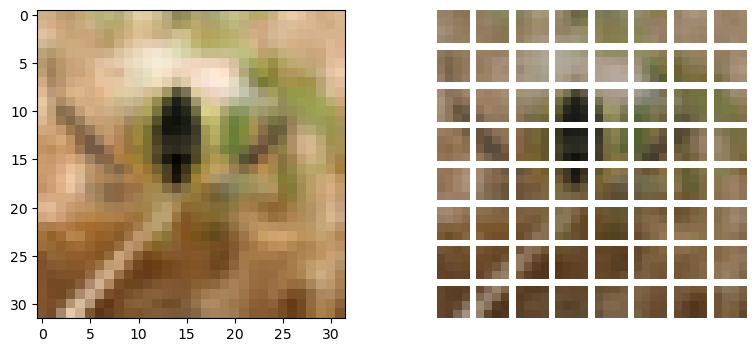

In [6]:
# Get a batch of images.
image_batch = x_train[0:BATCH_SIZE, :]

# Augment the images.
augmented_images = data_augmentation(image_batch)

# Define the patch layer.
patch_layer = Patches(patch_size = PATCH_SIZE)

# Get the patches from the batched images.
patches = patch_layer(images=augmented_images)

# Now pass the images and the corresponding patches
# to the `show_patched_image` method.
random_index = patch_layer.show_patched_image(images=augmented_images, patches=patches)

### Patch Encoding

Now we need to encoder our patches - but here we start to differ from our VIT example. In the batch encoder we introduce our masking. Essentially, once we've split our image into patches we'll then select some random indexes and mask out those patches. Masking these patches just involves replacing the tokens for those patches with a *mask token*, which is learnable itself, and the network will learn to recognise that this means it needs to fill in the blanks for that token.

We'll setup the encoder with an option, `downstream`, that we turn off if we want to disable the masking. This will mean that once we've pre-trained out network, we can simply switch off the masking in the patch encoder and use it like a regular VIT.

In [7]:
class PatchEncoder(layers.Layer):
    def __init__(
        self,
        patch_size=PATCH_SIZE,
        projection_dim=ENC_PROJECTION_DIM,
        mask_proportion=MASK_PROPORTION,
        downstream=False,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.projection_dim = projection_dim
        self.mask_proportion = mask_proportion
        self.downstream = downstream

        # This is a trainable mask token initialized randomly from a normal
        # distribution.
        self.mask_token = tf.Variable(
            tf.random.normal([1, patch_size * patch_size * 3]), trainable=True
        )

    def build(self, input_shape):
        (_, self.num_patches, self.patch_area) = input_shape

        # Create the projection layer for the patches.
        self.projection = layers.Dense(units=self.projection_dim)

        # Create the positional embedding layer.
        self.position_embedding = layers.Embedding(
            input_dim=self.num_patches, output_dim=self.projection_dim
        )

        # Number of patches that will be masked.
        self.num_mask = int(self.mask_proportion * self.num_patches)

    def call(self, patches):
        # Get the positional embeddings.
        batch_size = tf.shape(patches)[0]
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        pos_embeddings = self.position_embedding(positions[tf.newaxis, ...])
        pos_embeddings = tf.tile(
            pos_embeddings, [batch_size, 1, 1]
        )  # (B, num_patches, projection_dim)

        # Embed the patches.
        patch_embeddings = (
            self.projection(patches) + pos_embeddings
        )  # (B, num_patches, projection_dim)
        
        if self.downstream:
            return patch_embeddings
        else:
            mask_indices, unmask_indices = self.get_random_indices(batch_size)
            # The encoder input is the unmasked patch embeddings. Here we gather
            # all the patches that should be unmasked.
            unmasked_embeddings = tf.gather(
                patch_embeddings, unmask_indices, axis=1, batch_dims=1
            )  # (B, unmask_numbers, projection_dim)

            # Get the unmasked and masked position embeddings. We will need them
            # for the decoder.
            unmasked_positions = tf.gather(
                pos_embeddings, unmask_indices, axis=1, batch_dims=1
            )  # (B, unmask_numbers, projection_dim)
            masked_positions = tf.gather(
                pos_embeddings, mask_indices, axis=1, batch_dims=1
            )  # (B, mask_numbers, projection_dim)

            # Repeat the mask token number of mask times.
            # Mask tokens replace the masks of the image.
            mask_tokens = tf.repeat(self.mask_token, repeats=self.num_mask, axis=0)
            mask_tokens = tf.repeat(
                mask_tokens[tf.newaxis, ...], repeats=batch_size, axis=0
            )

            # Get the masked embeddings for the tokens.
            masked_embeddings = self.projection(mask_tokens) + masked_positions
            return (
                unmasked_embeddings,  # Input to the encoder.
                masked_embeddings,  # First part of input to the decoder.
                unmasked_positions,  # Added to the encoder outputs.
                mask_indices,  # The indices that were masked.
                unmask_indices,  # The indices that were unmaksed.
            )

    def get_random_indices(self, batch_size):
        # Create random indices from a uniform distribution and then split
        # it into mask and unmask indices.
        rand_indices = tf.argsort(
            tf.random.uniform(shape=(batch_size, self.num_patches)), axis=-1
        )
        mask_indices = rand_indices[:, : self.num_mask]
        unmask_indices = rand_indices[:, self.num_mask :]
        return mask_indices, unmask_indices

    def generate_masked_image(self, patches, unmask_indices):
        # Choose a random patch and it corresponding unmask index.
        idx = np.random.choice(patches.shape[0])
        patch = patches[idx]
        unmask_index = unmask_indices[idx]

        # Build a numpy array of same shape as patch.
        new_patch = np.zeros_like(patch)

        # Iterate of the new_patch and plug the unmasked patches.
        count = 0
        for i in range(unmask_index.shape[0]):
            new_patch[unmask_index[i]] = patch[unmask_index[i]]
        return new_patch, idx

We'll quickly test our patch encoder now. We'll put out a set of patches, and have a look at the masked and original image. We can see that lots of detail has been masked out, but patches that are left do match-up nicely with what's in the original image.

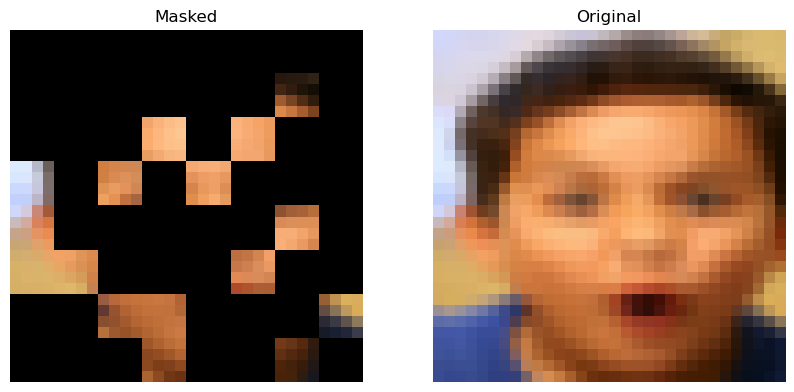

In [8]:
# Create the patch encoder layer.
patch_encoder = PatchEncoder()

unmasked_embeddings, masked_embeddings, unmasked_positions, mask_indices, unmask_indices = patch_encoder(patches=patches)

# Show a maksed patch image.
new_patch, random_index = patch_encoder.generate_masked_image(patches, unmask_indices)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
img = patch_layer.reconstruct_from_patch(new_patch)
plt.imshow(keras.utils.array_to_img(img))
plt.axis("off")
plt.title("Masked")
plt.subplot(1, 2, 2)
img = augmented_images[random_index]
plt.imshow(keras.utils.array_to_img(img))
plt.axis("off")
plt.title("Original")
plt.show()

### Encoder and Decoder

We'll now setup our encoder and decoder. These are actually going to look really similar, only the input and output of the two will really differ. The main part of them is pretty similar, with it just being a stack of transformer layers. Again, this should look pretty similar from the VIT example.

In [9]:
# small function to create a simple MLP
def mlp(x, hidden_units, dropout_rate):
    # create dense layers, with a drop-out in between
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

def create_encoder(num_heads=ENC_NUM_HEADS, num_layers=ENC_LAYERS):
    inputs = layers.Input((None, ENC_PROJECTION_DIM))
    encoded_patches = inputs

    # Create multiple layers of the Transformer block.
    for _ in range(num_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=ENC_PROJECTION_DIM, dropout=0.1)(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP.
        x3 = mlp(x3, hidden_units=ENC_TRANSFORMER_UNITS, dropout_rate=0.1)
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])

    # Create a [batch_size, projection_dim] tensor.
    output = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)

    return keras.Model(inputs, output, name="mae_encoder")

def create_decoder(num_layers=DEC_LAYERS, num_heads=DEC_NUM_HEADS, image_size=IMAGE_SIZE):
    
    inputs = layers.Input((NUM_PATCHES, ENC_PROJECTION_DIM))
    decoded_patches = layers.Dense(DEC_PROJECTION_DIM)(inputs)

    for _ in range(num_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(decoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=DEC_PROJECTION_DIM, dropout=0.1)(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, decoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP.
        x3 = mlp(x3, hidden_units=DEC_TRANSFORMER_UNITS, dropout_rate=0.1)
        # Skip connection 2.
        decoded_patches = layers.Add()([x3, x2])

    # Create a [batch_size, projection_dim] tensor.
    x = layers.LayerNormalization(epsilon=1e-6)(decoded_patches)
    x = layers.Flatten()(x)
    pre_final = layers.Dense(units=image_size * image_size * 3, activation="sigmoid")(x)
    outputs = layers.Reshape((image_size, image_size, 3))(pre_final)

    return keras.Model(inputs, outputs, name="mae_decoder")    

### Building and Evaluating a VIT

To give us something to compare to, let's build a VIT from these components.

I'm going to make one change from our VIT in the previous example. Rather than flatten all our tokens after our transformer block, I'm going to use a `GlobalAveragePooling1D`. Using a pooling approach is far more common in the literature, and will lead to a much more parameter efficient model. By doing this with the shallow encoder I'm using I am probably losing a couple of percent of accuracy, but using this feels more correct. 

For those thinking "Hang on, we're using images, why isn't it a 2D pooling operation?", good question. We've started with an image, but then broken it into a sequence patches. After the transformer blocks, what we have is a sequence of tokens and we want to pool those tokens. So while our input is 2D, a 1D pooling is appropriate here due to way that we're representing the data.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patches_1 (Patches)             │ (None, 64, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_encoder_1 (PatchEncoder)  │ (None, 64, 128)        │        14,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mae_encoder (Functional)        │ (None, 64, 128)        │       660,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 704,612 (2.69 MB)

 Trainable params: 704,612 (2.69 MB)

 Non-trainable params: 0 (0.00 B)

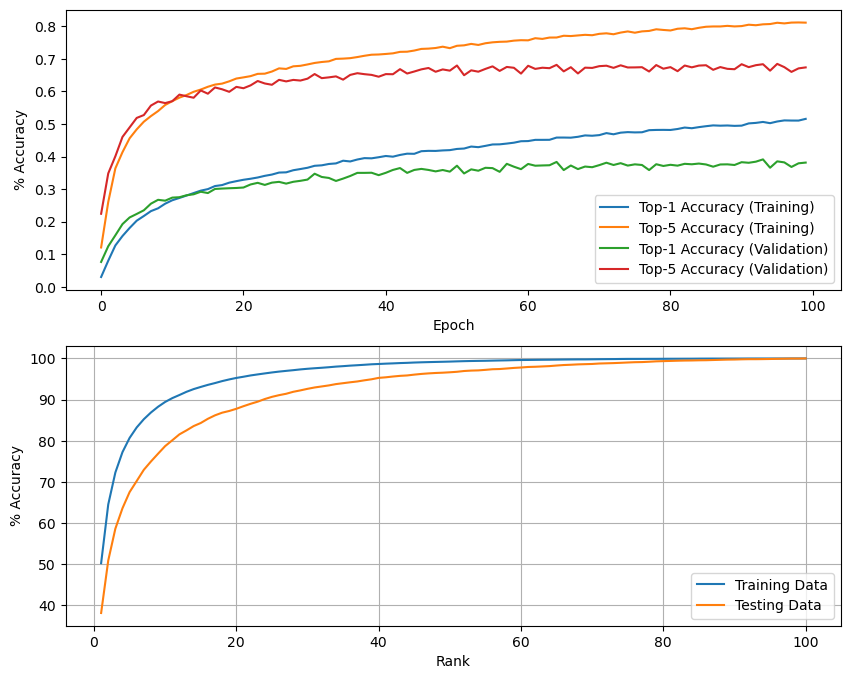

In [10]:
def build_downstream_model(data_augmentation, patch_layer, patch_encoder, encoder):
    # disable patch masking
    patch_encoder.downstream = True

    # Pack components as a model, adding a classification head
    downstream_model = keras.Sequential([layers.Input((IMAGE_SIZE, IMAGE_SIZE, 3)),
                                         data_augmentation,
                                         patch_layer,
                                         patch_encoder,
                                         encoder,
                                         layers.GlobalAveragePooling1D(),
                                         layers.Dense(128),
                                         layers.Dropout(0.5),
                                         layers.Dense(NUM_CLASSES, activation="softmax")])

    return downstream_model

def eval_model(history, model):

    train_predictions = model.predict(x_train, verbose=False)
    test_predictions = model.predict(x_test, verbose=False)
    train_samples = len(x_train)
    test_samples = len(x_test)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(2, 1, 1)
    plt.plot(history.history["accuracy"], label="Top-1 Accuracy (Training)")
    plt.plot(history.history["top-5-accuracy"], label="Top-5 Accuracy (Training)")
    plt.plot(history.history["val_accuracy"], label="Top-1 Accuracy (Validation)")
    plt.plot(history.history["val_top-5-accuracy"], label="Top-5 Accuracy (Validation)")
    plt.xlabel('Epoch')
    plt.ylabel('% Accuracy')
    plt.legend()
    
    cmc_train = []
    cmc_test = []
    rank = []
    for i in range(1,101):
        cmc_train.append(100.0*np.sum(tf.math.in_top_k(tf.argmax(y_train, axis=1), train_predictions, i))/train_samples)
        cmc_test.append(100.0*np.sum(tf.math.in_top_k(tf.argmax(y_test, axis=1), test_predictions, i))/test_samples)
        rank.append(i)

    ax = fig.add_subplot(2, 1, 2)
    plt.plot(rank, cmc_train, label="Training Data")
    plt.plot(rank, cmc_test, label="Testing Data")
    plt.grid()
    plt.legend()
    plt.xlabel('Rank')
    plt.ylabel('% Accuracy')

# create a VIT    
vanilla_vit = build_downstream_model(data_augmentation, Patches(), PatchEncoder(), create_encoder())
vanilla_vit.summary()

# train the model
vanilla_vit.compile(optimizer=keras.optimizers.AdamW(), loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
                    metrics=[keras.metrics.CategoricalAccuracy(name="accuracy"),
                             keras.metrics.TopKCategoricalAccuracy(5, name="top-5-accuracy")])
history = vanilla_vit.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=EPOCHS, batch_size = BATCH_SIZE, verbose=False)
eval_model(history, vanilla_vit)

Performance wise, the model goes ok, and gets very similar results to our previous VIT model. This is what we'd expected.

## Mased Autoencoder

Let's know setup the masked autoencoder. 

I'm going to follow what's done in the keras example and set this up as a class, which does mean I need to do a couple of things like specify what training and testing steps look like in the model - but this is not complex either. I will make some concessions though and remove the learning rate scheduler and a reporting callback to keep it a bit simpler.

In [11]:
class MaskedAutoencoder(keras.Model):
    def __init__(
        self,
        train_augmentation_model,
        patch_layer,
        patch_encoder,
        encoder,
        decoder,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.train_augmentation_model = train_augmentation_model
        self.patch_layer = patch_layer
        self.patch_encoder = patch_encoder
        self.encoder = encoder
        self.decoder = decoder

    def calculate_loss(self, images, test=False):
        # Augment the input images.
        if test:
            augmented_images = images
        else:
            augmented_images = self.train_augmentation_model(images)

        patches = self.patch_layer(augmented_images)

        # Encode the patches.
        (
            unmasked_embeddings,
            masked_embeddings,
            unmasked_positions,
            mask_indices,
            unmask_indices,
        ) = self.patch_encoder(patches)

        # Pass the unmaksed patche to the encoder.
        encoder_outputs = self.encoder(unmasked_embeddings)

        # Create the decoder inputs.
        encoder_outputs = encoder_outputs + unmasked_positions
        decoder_inputs = tf.concat([encoder_outputs, masked_embeddings], axis=1)

        # Decode the inputs.
        decoder_outputs = self.decoder(decoder_inputs)
        decoder_patches = self.patch_layer(decoder_outputs)

        loss_patch = tf.gather(patches, mask_indices, axis=1, batch_dims=1)
        loss_output = tf.gather(decoder_patches, mask_indices, axis=1, batch_dims=1)

        # Compute the total loss.
        total_loss = self.compute_loss(y=loss_patch, y_pred=loss_output)

        return total_loss, loss_patch, loss_output

    def train_step(self, images):
        with tf.GradientTape() as tape:
            total_loss, loss_patch, loss_output = self.calculate_loss(images)

        # Apply gradients.
        train_vars = [
            self.train_augmentation_model.trainable_variables,
            self.patch_layer.trainable_variables,
            self.patch_encoder.trainable_variables,
            self.encoder.trainable_variables,
            self.decoder.trainable_variables,
        ]
        grads = tape.gradient(total_loss, train_vars)
        tv_list = []
        for grad, var in zip(grads, train_vars):
            for g, v in zip(grad, var):
                tv_list.append((g, v))
        self.optimizer.apply_gradients(tv_list)

        # Report progress.
        results = {}
        for metric in self.metrics:
            metric.update_state(loss_patch, loss_output)
            results[metric.name] = metric.result()
        return results

    def test_step(self, images):
        total_loss, loss_patch, loss_output = self.calculate_loss(images, test=True)

        # Update the trackers.
        results = {}
        for metric in self.metrics:
            metric.update_state(loss_patch, loss_output)
            results[metric.name] = metric.result()
        return results

Now we can train our model. We'll train this for the same number of epochs we trained the VIT above for.

In [12]:
# create the model
mae_model = MaskedAutoencoder(train_augmentation_model=data_augmentation, patch_layer=Patches(), patch_encoder=PatchEncoder(),
                              encoder=create_encoder(), decoder=create_decoder())

# Compile and train the model.
mae_model.compile(optimizer=keras.optimizers.AdamW(weight_decay=WEIGHT_DECAY), 
                  loss=keras.losses.MeanSquaredError(), metrics=["mae"])
history = mae_model.fit(x_train, batch_size = BATCH_SIZE, epochs=EPOCHS, validation_data=(x_val, None), verbose=False)

And now we'll visualise some outputs from the model.

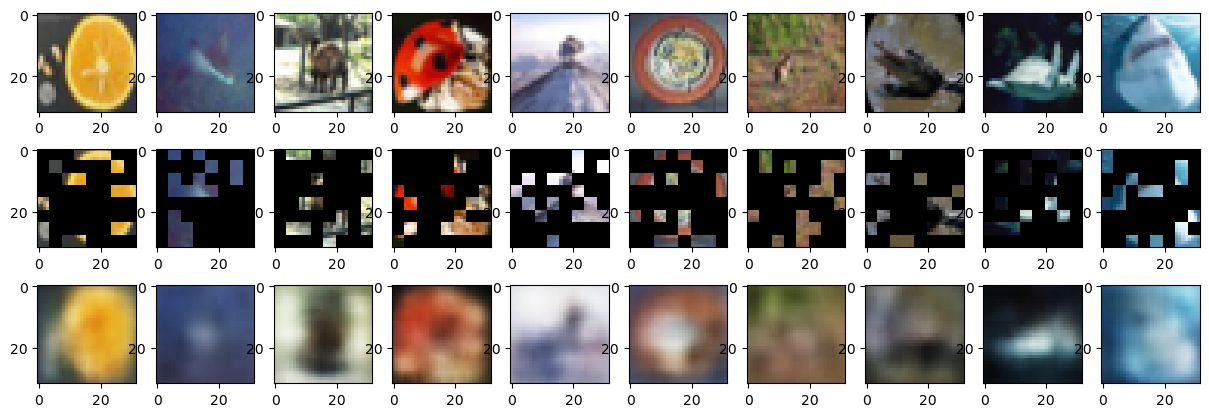

In [13]:
test_images = x_test[0:100, :]
test_patches = mae_model.patch_layer(test_images)
(test_unmasked_embeddings, test_masked_embeddings, test_unmasked_positions, test_mask_indices, test_unmask_indices) = mae_model.patch_encoder(test_patches)
test_encoder_outputs = mae_model.encoder(test_unmasked_embeddings)
test_encoder_outputs = test_encoder_outputs + test_unmasked_positions
test_decoder_inputs = tf.concat([test_encoder_outputs, test_masked_embeddings], axis=1)
test_decoder_outputs = mae_model.decoder(test_decoder_inputs)

fig, ax = plt.subplots(nrows=3, ncols=10, figsize=(15, 5))
for r in range(10):

    test_masked_patch, idx = mae_model.patch_encoder.generate_masked_image(test_patches, test_unmask_indices)        
    ax[0][r].imshow(test_images[idx])
    ax[1][r].imshow(mae_model.patch_layer.reconstruct_from_patch(test_masked_patch))
    ax[2][r].imshow(test_decoder_outputs[idx])

We can see the MAE doesn't get great reconstructions - there's a fair bit of blur there and not a lot of detail, but the overall shape of objects, and colours, are pretty right. Really here, we're limited by three things:
* The network is not that big/deep
* Our images are very small and blurry to start with, so there's only so much scope
* We could keep training

None the less, it's clear the network has learned something. 

### Fine-tuning our MAE

Let's now setup our downstream model. We''ll pull out the network components from the MAE and repurpose those in our downstream model. I'm then going to train in two stages:
* In the first stage, I'll just train the classification head we've added, freezing the encoder. Here I'll train for just a few small number of epochs.
* In the second stage, I'll unfreeze the encoder and jointly fine-tune the lot. Here, I'll fine tune for a lot longer.

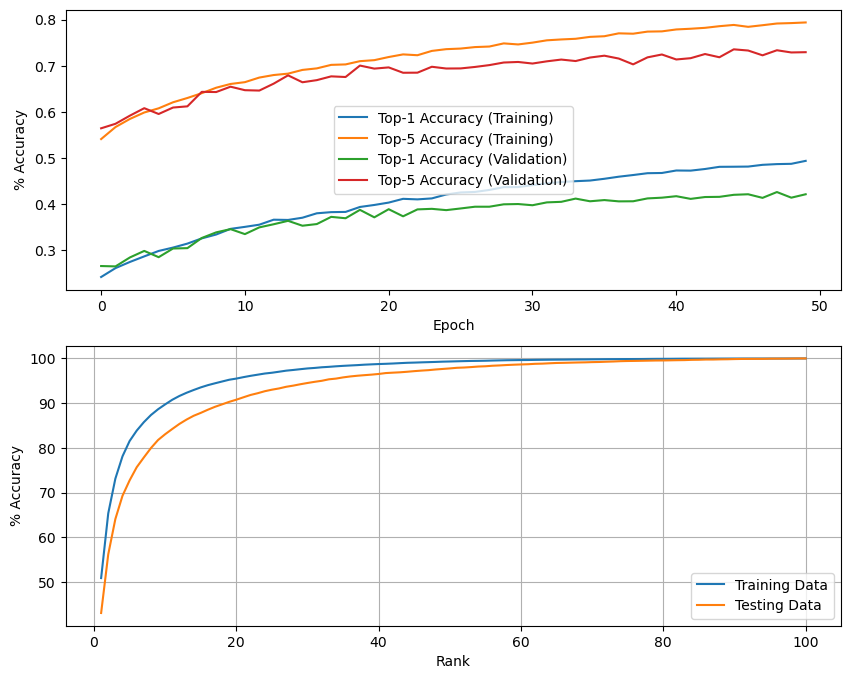

In [14]:
# create our classification model using the various parts from our MAE
pretrained_vit = build_downstream_model(mae_model.train_augmentation_model, mae_model.patch_layer, mae_model.patch_encoder, mae_model.encoder)

# freeze the encoder
for layer in pretrained_vit.layers[:-5]:
    layer.trainable = False

# train for a short period of time, just tuning the classification head we added
pretrained_vit.compile(optimizer=keras.optimizers.AdamW(), loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1), 
                       metrics=[keras.metrics.CategoricalAccuracy(name="accuracy"), 
                                keras.metrics.TopKCategoricalAccuracy(5, name="top-5-accuracy")])
history = pretrained_vit.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=EPOCHS // 20, batch_size = BATCH_SIZE, verbose=False)

# unfreeze the encoder
for layer in pretrained_vit.layers[-7:]:
    layer.trainable = True

# train again
pretrained_vit.compile(optimizer=keras.optimizers.AdamW(), loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
                       metrics=[keras.metrics.CategoricalAccuracy(name="accuracy"),
                                keras.metrics.TopKCategoricalAccuracy(5, name="top-5-accuracy")])
history = pretrained_vit.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=EPOCHS // 2, batch_size = BATCH_SIZE, verbose=False)
# evaluate
eval_model(history, pretrained_vit)

## Final Thoughts

We see our final model outperforms what we had above, and appears to be exhibiting less overfitting. It's also acheived this accuracy in about half the epochs of the VIT above (though that doesn't quite tell the whole story as we did pre-train the encoder first). The improved performance, and reduced overfitting, is down to first learning a good representation in a self-supervised manner and then tuning this on the task at hand. As always though with this sort of example with long run-times, there are a bunch of caveats:
* We've really not trained any of these networks for as long as we could. We could go longer and see better performance still.
* Our encoder could (should?) be more complex. Two encoder layers doesn't give us a great chance to learn a rich representation. Similarly, we could use larger embeddings. This would all have serious impacts on memory and run-time of course.
* We could do fancier things in training. Using a warm-up period and learning rate schedule (like the original example) is a good option. Similarly, we could do a better job setting different learning rates for our fine-tuning (and possibly just use SGD and a longer training time too).

Despite the above, this example hopefully provides a good idea of how masked pre-training works, and what the benefits are. In reality, this is the sort of process that you'd usually run for several hours on a decent workstation at a minimum - so it's not something that we're really expecting you to do in this unit. In practice, it's far more likley that you'd be downloading a pre-trained model that's been trained in this way, and adapting it to your task. That said, it's good to know how that model was trained in the first place.